In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data # Added import for skimage.data

# Function to display images
def imshow_components(components, titles=None, cmap='gray', fig_size=(15, 5)):
    n_components = len(components)
    if titles is None:
        titles = [f'Image {i+1}' for i in range(n_components)]

    fig, axes = plt.subplots(1, n_components, figsize=fig_size)

    if n_components == 1:
        axes.imshow(components[0], cmap=cmap)
        axes.set_title(titles[0])
        axes.axis('off')
    else:
        for i, ax in enumerate(axes):
            ax.imshow(components[i], cmap=cmap)
            ax.set_title(titles[i])
            ax.axis('off')
    plt.tight_layout()
    plt.show()

In [14]:
def add_gaussian_noise(image, mean=0, var=0.01):
    row, col = image.shape
    sigma = var**0.5
    gauss = np.random.normal(mean, sigma, (row, col))
    noisy_image = image + gauss
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

def add_salt_and_pepper_noise(image, salt_vs_pepper=0.5, amount=0.04):
    noisy_image = np.copy(image)
    # Salt mode
    num_salt = np.ceil(amount * image.size * salt_vs_pepper)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    # Pepper mode
    num_pepper = np.ceil(amount * image.size * (1.0 - salt_vs_pepper))
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image.astype(np.uint8)


In [15]:
def arithmetic_mean_filter(image, kernel_size=(3, 3)):
    return cv2.blur(image, kernel_size)

def midpoint_filter(image, kernel_size=(3, 3)):
    rows, cols = image.shape
    k_h, k_w = kernel_size
    pad_h, pad_w = k_h // 2, k_w // 2

    padded_image = cv2.copyMakeBorder(image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_REFLECT)
    output_image = np.zeros_like(image, dtype=np.uint8)

    for i in range(rows):
        for j in range(cols):
            window = padded_image[i:i+k_h, j:j+k_w]
            output_image[i, j] = (np.min(window) + np.max(window)) / 2
    return output_image

def alpha_trimmed_mean_filter(image, kernel_size=(3, 3), d=2):
    rows, cols = image.shape
    k_h, k_w = kernel_size
    pad_h, pad_w = k_h // 2, k_w // 2

    padded_image = cv2.copyMakeBorder(image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_REFLECT)
    output_image = np.zeros_like(image, dtype=np.uint8)

    for i in range(rows):
        for j in range(cols):
            window = padded_image[i:i+k_h, j:j+k_w].flatten()
            window.sort()
            trimmed_window = window[d//2 : len(window) - d//2]
            output_image[i, j] = np.mean(trimmed_window)
    return output_image.astype(np.uint8)


Image file 'lena.png' not found locally or is invalid. Attempting to use skimage.data.camera() as fallback.
Successfully loaded 'camera' image from skimage.data.


/tmp/ipykernel_10460/3616892167.py:15: RuntimeWarning: overflow encountered in scalar add
  output_image[i, j] = (np.min(window) + np.max(window)) / 2


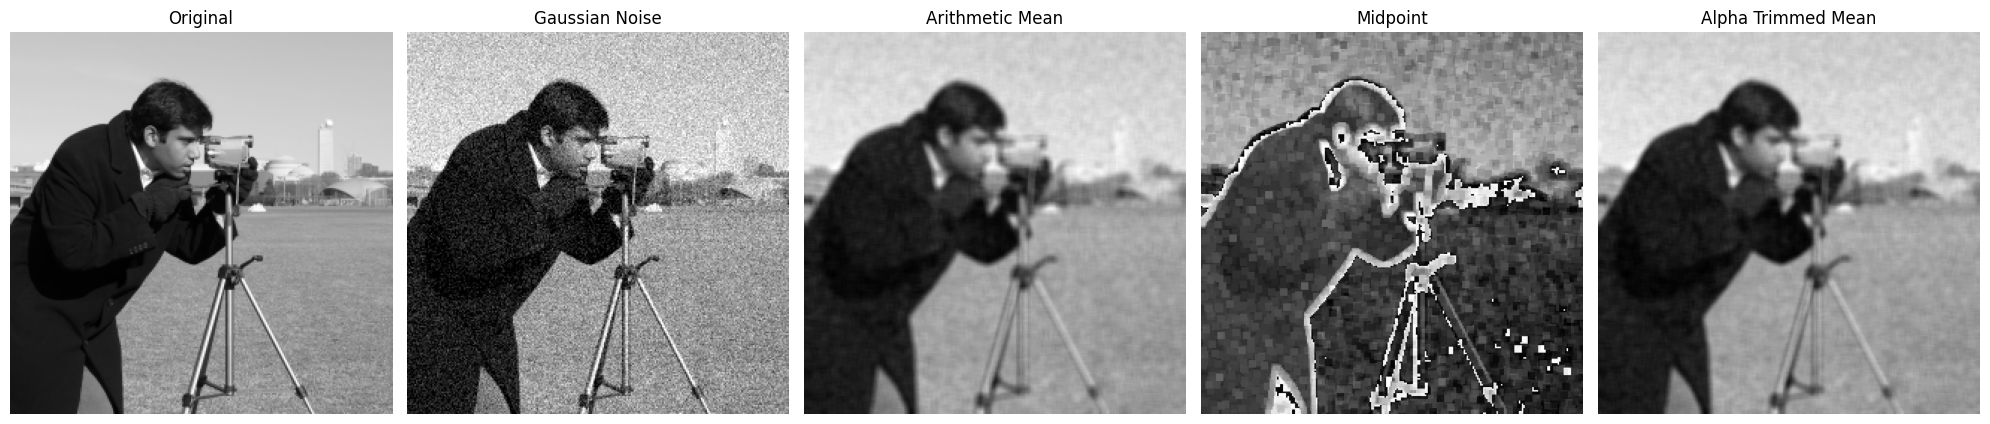

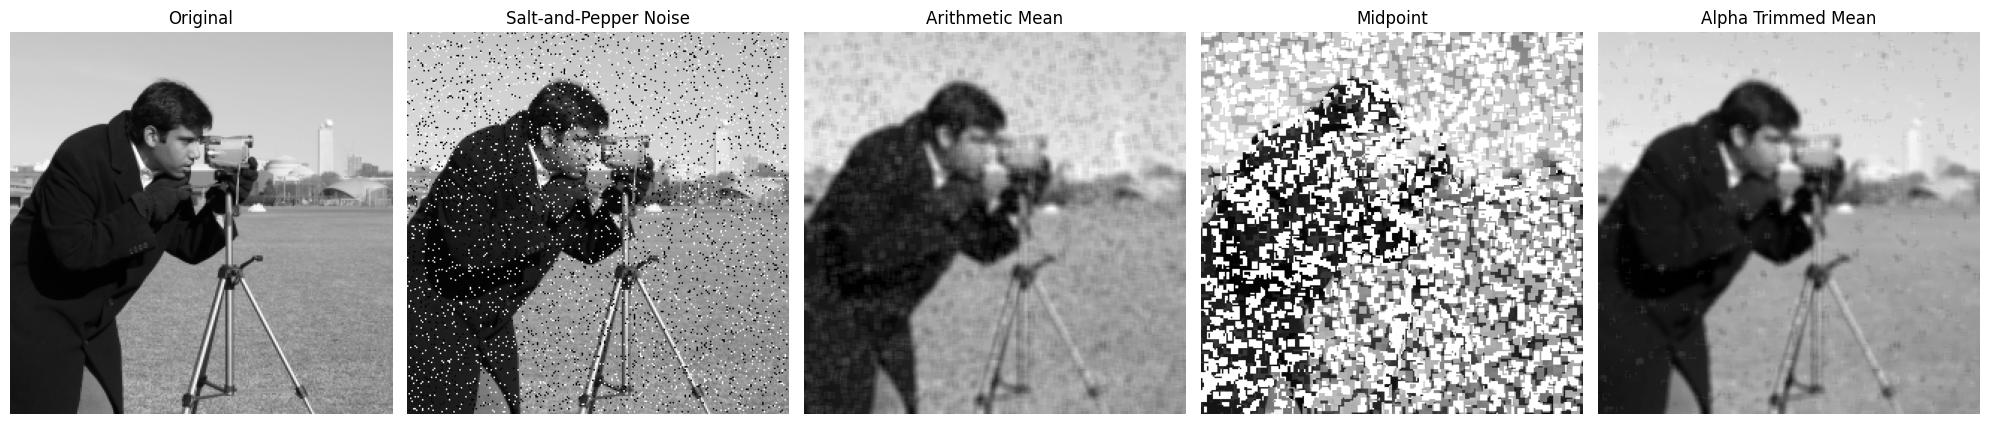

In [16]:
# Load an example image (make sure you have 'lena.png' or any other image in your Colab environment)
# You can upload an image by clicking the folder icon on the left panel.
image_path = 'lena.png'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Image file '{image_path}' not found locally or is invalid. Attempting to use skimage.data.camera() as fallback.")
    try:
        # Use skimage.data.camera() which is a standard grayscale test image
        original_image = data.camera()
        print("Successfully loaded 'camera' image from skimage.data.")
    except Exception as e:
        print(f"Failed to load 'camera' image from skimage.data: {e}")
        print("Please ensure scikit-image is installed and functional, or manually upload a valid 'lena.png' file.")
        raise RuntimeError("Failed to load image for processing.")

# The image loaded from skimage.data.camera() is already grayscale.
# If original_image was loaded from file, it's also grayscale.
original_image = cv2.resize(original_image, (256, 256)) # Resize for consistent demonstration

# Add Gaussian Noise
gaussian_noisy_image = add_gaussian_noise(original_image, mean=0, var=400)

# Add Salt-and-Pepper Noise
salt_pepper_noisy_image = add_salt_and_pepper_noise(original_image, amount=0.08)

# Apply filters to Gaussian noisy image
gaussian_restored_arith = arithmetic_mean_filter(gaussian_noisy_image, kernel_size=(5, 5))
gaussian_restored_midpoint = midpoint_filter(gaussian_noisy_image, kernel_size=(5, 5))
gaussian_restored_alpha = alpha_trimmed_mean_filter(gaussian_noisy_image, kernel_size=(5, 5), d=4)

# Apply filters to Salt-and-Pepper noisy image
salt_pepper_restored_arith = arithmetic_mean_filter(salt_pepper_noisy_image, kernel_size=(5, 5))
salt_pepper_restored_midpoint = midpoint_filter(salt_pepper_noisy_image, kernel_size=(5, 5))
salt_pepper_restored_alpha = alpha_trimmed_mean_filter(salt_pepper_noisy_image, kernel_size=(5, 5), d=4)


# Display results for Gaussian Noise
imshow_components(
    [original_image, gaussian_noisy_image, gaussian_restored_arith, gaussian_restored_midpoint, gaussian_restored_alpha],
    titles=['Original', 'Gaussian Noise', 'Arithmetic Mean', 'Midpoint', 'Alpha Trimmed Mean'],
    fig_size=(20, 5)
)

# Display results for Salt-and-Pepper Noise
imshow_components(
    [original_image, salt_pepper_noisy_image, salt_pepper_restored_arith, salt_pepper_restored_midpoint, salt_pepper_restored_alpha],
    titles=['Original', 'Salt-and-Pepper Noise', 'Arithmetic Mean', 'Midpoint', 'Alpha Trimmed Mean'],
    fig_size=(20, 5)
)
